#### **NLP中的强化学习**

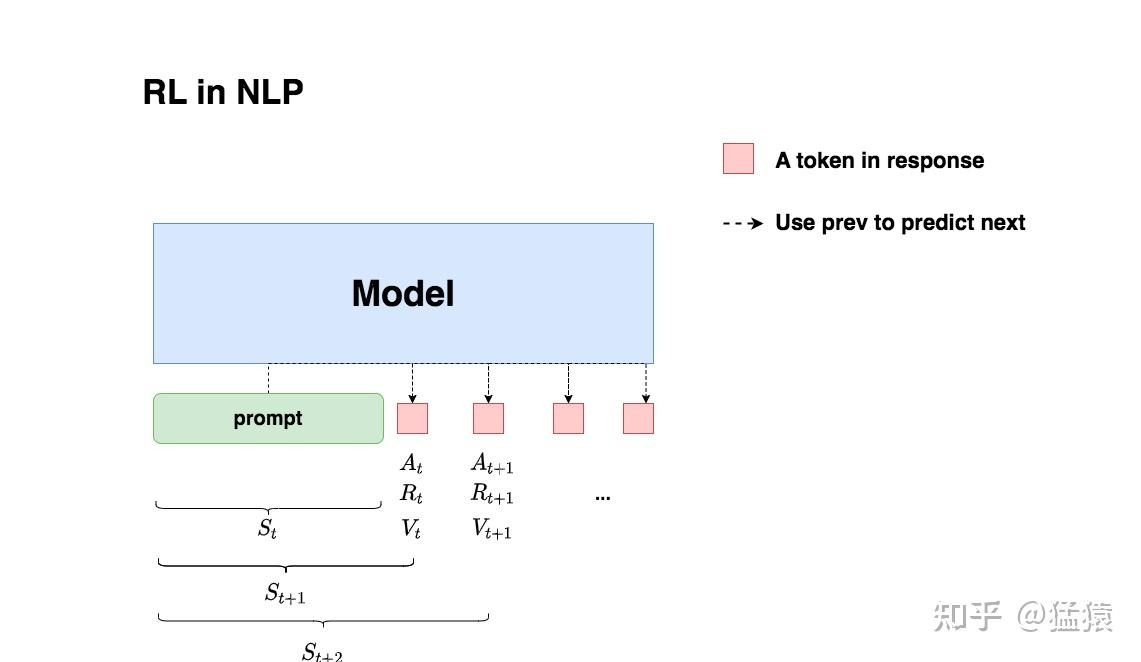

*   **目标：** 给模型一个prompt，让模型生成符合人类喜好的回答
*   **动作：** t时刻，模型根据上文，产出一个token
*   **即时收益：** 模型生成token后获得的收益，同理未来收益就是模型生成token后，对之后收益的估计

*   **RLHF中的四个重要角色**
    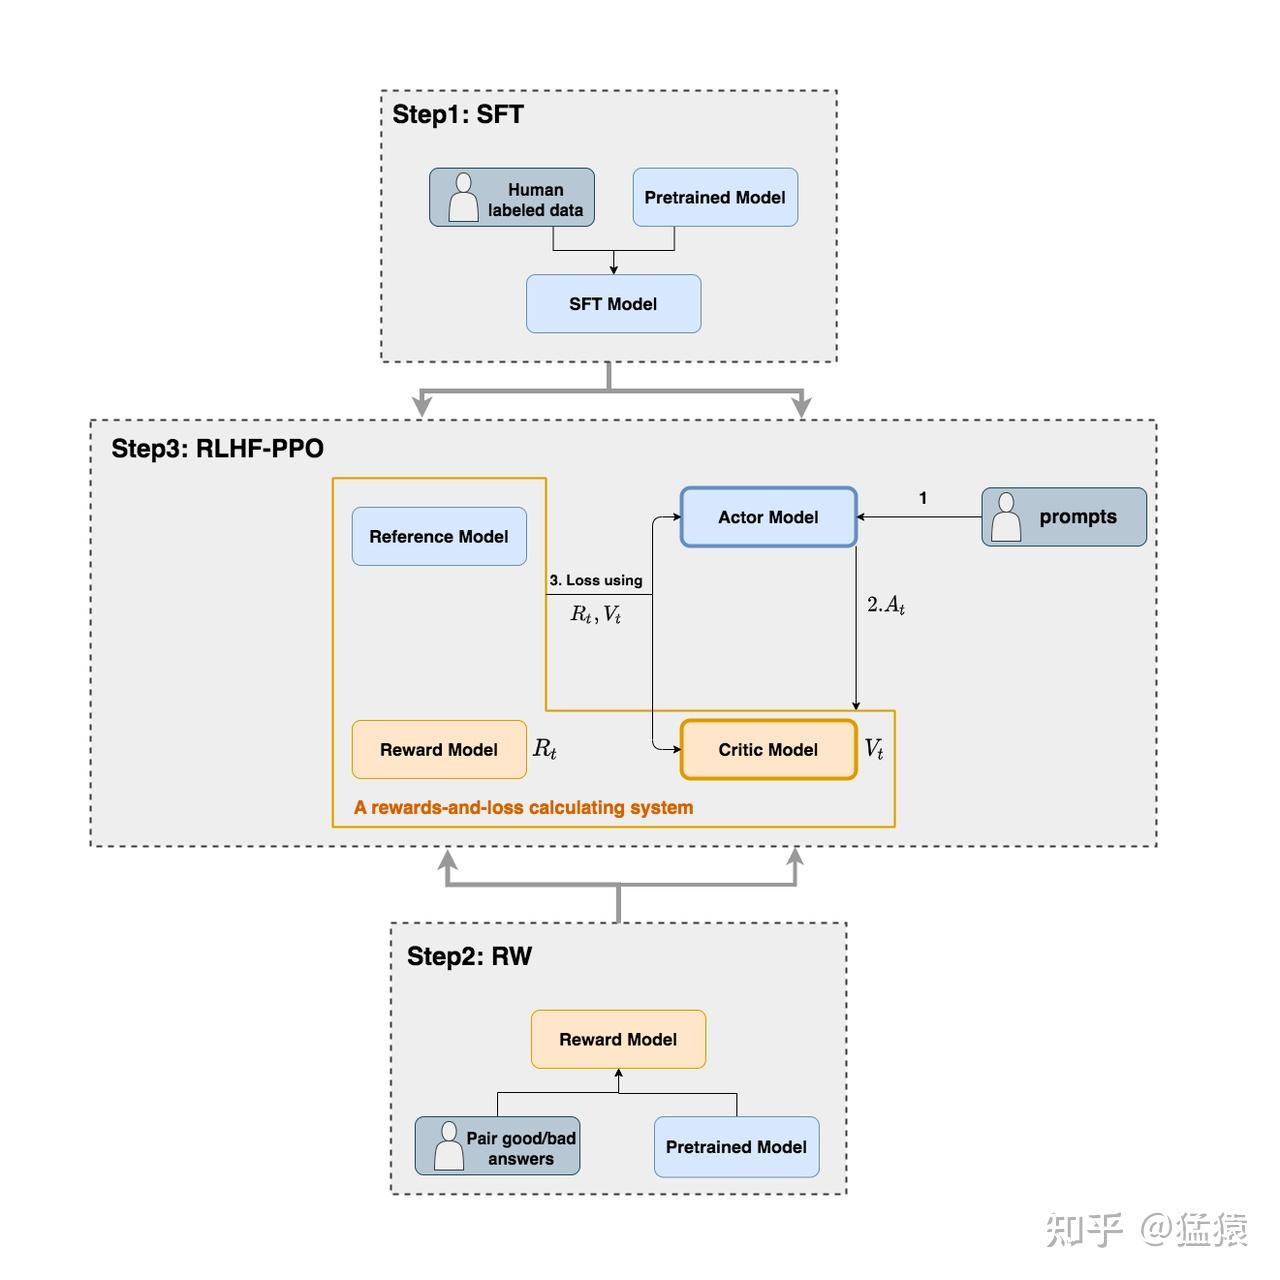
    1.  **Actor Model：** 想要训练的目标语言模型，一般是SFT阶段产出的SFT模型。
    2.  **Reference Model：** 也用SFT模型初始化，但参数冻结，防止训练过程中Actor模型与SFT模型差异过大（用KL散度来表示两个模型的差距）。
        *   把Actor生成的"prompt + response"喂给ref，得到每个response token的概率ref_log_probs，
    ref_log_probs - log_probs 越大说明偏离原模型越小
    3.  **Critic Model：** 用于预测期望总收益。和Actor模型一样，它需要做参数更新。实践中，Critic Model的设计和初始化方式也有很多种，例如和Actor共享部分参数、从RW阶段的Reward Model初始化而来等等。
    4.  **Reward Model：** 用于计算某动作的即时收益，参数是冻结的。与Critic Model不同，reward模型经过了提前训练。

*   **RLHF中的loss计算**
    1.  **Actor loss：** 
        * 直观设计：
        
        * 引入优势（剔除了“当前状态本身的好坏”这个背景噪音，只保留了“动作本身的好坏”这个最关键的信号。这个信号更纯粹、更稳定（即方差低））：
        
        即实际的收益减去critic model对总收益的预测
        * 重新设计即时奖励Rt：

        $R_t = -kl\_ctl \cdot \left( \log \frac{P(A_t|S_t)}{P_{ref}(A_t|S_t)} \right)$
        $R_T = -kl\_ctl \cdot \left( \log \frac{P(A_T|S_T)}{P_{ref}(A_T|S_T)} \right) + R_{RM}$

        即中间每一步的即时奖励是是否和参考模型偏离过远。最后一步才加上奖励模型（RM）对完整的 (prompt, response) 对给出的最终分数

In [ ]:
def compute_rewards(self, prompts, log_probs, ref_log_probs, reward_score,
                        action_mask):
        """
        reward_function：计算最终的reward分数
        复习一下几个相关参数的默认值：
        self.kl_ctl = 0.1
        self.clip_reward_value = 5
        
        对于batch中的某个prompt来说，它最终的reward分数为：
        (1) 先计算actor和ref_model的logit相似度： -self.kl_ctl * (log_probs - ref_log_probs)
            其实写成self.kl_ctl * (ref_log_probs - log_probs)更好理解些
            这个值越大，说明ref_model对actor生成的结果的认可度越高（即表明rlhf没有训歪），
            没有训歪的情况下我们也应该给模型一些奖励，这个奖励就是self.kl_ctl * (ref_log_probs - log_probs)
            
        （2）由于我们只取最后一个token对应位置的分数作为reward_score，因此我们只需要：
            self.kl_ctl * (ref_log_probs - log_probs)的最后一位 + reward_score
         
         (3) 同时我们对reward_score也做了大小限制，最大不超过self.clip_reward_value（超过统一给成self.clip_reward_value），
             最小不低于-self.clip_reward_value（低于统一给成-self.clip_reward_value）
        
         (4) 最后返回的rewards大小为：（batch_size, 各条数据的长度），对batch中的每条数据来说：
             - response的最后一位：self.kl_ctl * (ref_log_probs - log_probs)的最后一位 + reward_score
             - response的其余位置：self.kl_ctl * (ref_log_probs - log_probs)
        
        """

        kl_divergence_estimate = -self.kl_ctl * (log_probs - ref_log_probs)
        rewards = kl_divergence_estimate
        # ---------------------------------------------------------------------------------------------------
        # response开始的位置
        # （因为我们对prompt做过padding处理，因此batch中每个prompt长度一致，也就意味着每个response开始的位置一致）
        # （所以这里start是不加s的，只是一个int）
        # ---------------------------------------------------------------------------------------------------
        start = prompts.shape[1] - 1
        # ---------------------------------------------------------------------------------------------------
        # response结束的位置
        # （因为一个batch中，每个response的长度不一样，所以response的结束位置也不一样）
        # （所以这里end是加s的，ends的尺寸是(batch_size,)
        # ---------------------------------------------------------------------------------------------------
        ends = start + action_mask[:, start:].sum(1) + 1
        # ---------------------------------------------------------------------------------------------------
        # 对rewards_score做限制
        # ---------------------------------------------------------------------------------------------------
        reward_clip = torch.clamp(reward_score, -self.clip_reward_value,
                                  self.clip_reward_value)
        batch_size = log_probs.shape[0]
        for j in range(batch_size):
            rewards[j, start:ends[j]][-1] += reward_clip[j] # 

        return rewards

* 优势函数改造：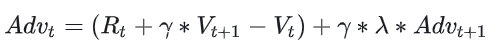

In [ ]:
def get_advantages_and_returns(self, values, rewards, start):
        """
        Adopted from https://github.com/CarperAI/trlx/blob/main/trlx/models/modeling_ppo.py#L134
        
        没有引入GAE前的t时刻的优势值：
        detal_t = r_t + gamma * V_t+1 - V_t
        其中：
            - r_t表示t时刻的即时收益
            - V_t+1表示未来时刻的预期收益
            - r_t + gamma * V_t+1可理解成t时刻的实际预期收益
            - V_t可理解成t时刻的预估预期收益（是模型，例如critic model自己估算出来的）
        
        引入GAE后的t时刻的优势值：
        A_t = delta_t + gamma * lambda * A_t+1
        粗暴理解为在t时刻时，不仅考虑当下优势，还考虑了未来的优势
        为了知道A_t, 我们得知道A_t+1，所以在本算法中采取了从后往前做动态规划求解的方法，也即：
        假设T是最后一个时刻，则有A_T+1 = 0, 所以有: A_T = delta_T
        知道了A_T, 就可以依次往前倒推，把A_t-1, A_t-2之类都算出来了
        
        引入GAE后t时刻的实际预期收益
        returns_t = A_t + V_t
                  = delta_t + gamma * lambda * A_t+1 + V_t
                  = r_t + gamma * V_t+1 - V_t + gamma * lambda * A_t+1 + V_t
                  = r_t + gamma * (V_t+1 + lambda * A_t+1)
        
        注意，这里不管是advantages还是returns，都只算response的部分
        """
        
        # Adopted from https://github.com/CarperAI/trlx/blob/main/trlx/models/modeling_ppo.py#L134
        lastgaelam = 0
        advantages_reversed = []
        length = rewards.size()[-1]
        # 注意这里用了reversed，是采取从后往前倒推计算的方式
        for t in reversed(range(start, length)):
            nextvalues = values[:, t + 1] if t < length - 1 else 0.0
            delta = rewards[:, t] + self.gamma * nextvalues - values[:, t]
            lastgaelam = delta + self.gamma * self.lam * lastgaelam
            advantages_reversed.append(lastgaelam)
        advantages = torch.stack(advantages_reversed[::-1], dim=1) # 优势
        returns = advantages + values[:, start:] # 实际收益
        # values: 预期收益
        return advantages.detach(), returns